# Эксперимент LightGBM на подготовленных признаках

Notebook проверяет `lightgbm.LGBMClassifier` на уже подготовленных признаках из `data/X_train_prepared.csv` и таргете из `data/y_train.csv`.

Что считается:
- out-of-fold прогнозы через `StratifiedKFold`;
- precision, recall, ROC-AUC OVR, average precision macro/weighted;
- поклассовые метрики;
- подбор threshold для классов `1` и `2` (`Standard` и `Good`) с максимизацией precision при ограничении на минимальный recall;
- сравнение обычного `argmax` и thresholded-предсказаний;
- PR-кривые.

Notebook ничего не сохраняет на диск и только выводит таблицы/графики.


## Импорты и зависимости

`lightgbm` не устанавливается автоматически. Если пакет отсутствует в активном окружении, следующая ячейка остановится с явным сообщением, что нужно установить.


In [2]:
from pathlib import Path
from typing import Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, label_binarize

try:
    from lightgbm import LGBMClassifier
except ImportError as exc:
    raise ImportError(
        "Пакет lightgbm не установлен в активном окружении. "
        "Установите его вручную, например: pip install lightgbm. "
        "Этот notebook не меняет окружение автоматически."
    ) from exc

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 180)

PROJECT_ROOT = Path.cwd()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / "data" / "X_train_prepared.csv").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Не найден data/X_train_prepared.csv относительно текущей директории.")

PROJECT_ROOT


WindowsPath('C:/Users/stoli/PycharmProjects/Credit_score')

## Настройки эксперимента

Классы в таргете ожидаются в формате `0 = Poor`, `1 = Standard`, `2 = Good`. Threshold подбирается для `Standard` и `Good`; минимальный recall можно изменить в `MIN_RECALL_BY_CLASS`.


In [3]:
FEATURES_PATH = PROJECT_ROOT / "data" / "X_train_prepared.csv"
TARGET_PATH = PROJECT_ROOT / "data" / "y_train.csv"
TARGET = "Credit_Score"
INDEX_COLUMN = "source_index"

N_SPLITS = 5
RANDOM_STATE = 42

CLASS_NAMES = {
    "0": "Poor",
    "1": "Standard",
    "2": "Good",
}

PRIORITY_CLASSES = [1, 2]
DEFAULT_MIN_RECALL = 0.50
MIN_RECALL_BY_CLASS = {
    1: 0.50,
    2: 0.50,
}

LGBM_PARAMS = {
    "max_depth": 12,
    "n_estimators": 900,
    "learning_rate": 0.03785428774804801,
    "num_leaves": 123,
    "min_child_samples": 52,
    "subsample": 0.7702220909795412,
    "subsample_freq": 1,
    "colsample_bytree": 0.7921685120580458,
    "reg_alpha": 0.006472850773928197,
    "reg_lambda": 5.165584218767955e-07,
    "min_split_gain": 0.10544284089315753,
    "objective": "multiclass",
    "boosting_type": "gbdt",
    "class_weight": "balanced",
    "random_state": 42,
    "n_jobs": -1,
    "verbosity": -1
}


## Загрузка и выравнивание данных

`X_train_prepared.csv` и `y_train.csv` выравниваются строго по `source_index`. После merge колонка `source_index` удаляется из признаков, чтобы модель не училась на техническом индексе.


In [4]:
def load_prepared_data(
    features_path: Path,
    target_path: Path,
    target: str,
    index_column: str,
) -> tuple[pd.DataFrame, pd.Series]:
    features = pd.read_csv(features_path)
    target_data = pd.read_csv(target_path)

    required_target_columns = {index_column, target}
    missing_target_columns = required_target_columns.difference(target_data.columns)
    if missing_target_columns:
        raise ValueError(f"В target-файле нет колонок: {sorted(missing_target_columns)}")

    if index_column not in features.columns:
        raise ValueError(f"В feature-файле нет колонки {index_column!r}.")

    data = features.merge(
        target_data[[index_column, target]],
        on=index_column,
        how="inner",
        validate="one_to_one",
    )

    if len(data) != len(features) or len(data) != len(target_data):
        raise ValueError(
            "Feature и target файлы не совпадают по source_index: "
            f"features={len(features)}, target={len(target_data)}, after_merge={len(data)}."
        )

    y = data[target].copy()
    X = data.drop(columns=[target, index_column]).copy()

    non_numeric_columns = X.select_dtypes(exclude=[np.number]).columns.tolist()
    if non_numeric_columns:
        raise ValueError(f"В признаках остались нечисловые колонки: {non_numeric_columns}")

    if X.isna().any().any():
        missing_counts = X.isna().sum().loc[lambda values: values > 0].sort_values(ascending=False)
        raise ValueError(f"В признаках есть пропуски:\n{missing_counts.head(20)}")

    if y.isna().any():
        raise ValueError("В target есть пропуски.")

    return X, y


X, y = load_prepared_data(FEATURES_PATH, TARGET_PATH, TARGET, INDEX_COLUMN)

display(pd.DataFrame({"rows": [len(X)], "features": [X.shape[1]], "classes": [y.nunique()]}))
display(y.value_counts().sort_index().rename_axis(TARGET).to_frame("rows"))
X.head()


,rows,features,classes
0,80000,84,3


,rows
Credit_Score,
0,23199
1,42539
2,14262


,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_History_Age_Months,Month_Num,Loan_Type_Count,Loan_Type__Auto Loan,Loan_Type__Credit-Builder Loan,Loan_Type__Debt Consolidation Loan,Loan_Type__Home Equity Loan,Loan_Type__Mortgage Loan,Loan_Type__Not Specified,Loan_Type__Payday Loan,Loan_Type__Personal Loan,Loan_Type__Student Loan,debt_to_annual_income,debt_to_monthly_salary,emi_to_monthly_salary,investment_to_monthly_salary,balance_to_monthly_salary,available_income_after_emi,available_income_after_emi_and_investment,delayed_payment_ratio,avg_delay_per_delayed_payment,inquiries_per_credit_account,credit_cards_per_bank_account,loans_per_bank_account,credit_history_years,credit_age_per_loan,total_credit_products,loan_diversity_ratio,has_negative_payment_history,high_utilization_flag,low_balance_flag,debt_per_credit_product,Month_April,Month_August,Month_February,Month_January,Month_July,Month_June,Month_March,Month_May,Occupation_Accountant,Occupation_Architect,Occupation_Developer,Occupation_Doctor,Occupation_Engineer,Occupation_Entrepreneur,Occupation_Journalist,Occupation_Lawyer,Occupation_Manager,Occupation_Mechanic,Occupation_Media_Manager,Occupation_Musician,Occupation_Scientist,Occupation_Teacher,Occupation_Writer,Credit_Mix_Bad,Credit_Mix_Good,Credit_Mix_Standard,Credit_Mix_Пропуск,Payment_of_Min_Amount_NM,Payment_of_Min_Amount_No,Payment_of_Min_Amount_Yes,Payment_Behaviour_High_spent_Large_value_payments,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments
0,-0.030611,-0.611964,-0.642510,0.244190,-0.742425,-0.861474,-0.219725,-0.623109,0.985720,-0.393207,-1.505713,-0.554578,0.859029,-0.329758,-0.237681,-0.503647,-0.303578,-0.218091,-0.219659,-0.664802,-0.681172,-0.670319,-0.676692,1.479022,-0.681113,1.459163,-0.673161,1.489693,-0.362890,-0.343246,-0.047387,-0.148815,-0.037083,-0.637288,-0.419101,-0.031142,-0.657871,-1.410209,-0.608467,-0.379271,-0.303578,-0.285421,-0.544451,0.004903,0.038434,1.393106,-0.819264,-0.403018,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-1.554897,-0.424391,-0.471108,-0.913945,0.225329,0.396244,-0.628211,0.463582,1.065699,1.253837,0.580222,-0.227752,-1.404240,-0.407375,-0.284630,0.022808,-1.419108,0.218168,-0.628165,1.504208,-0.681172,-0.670319,1.477777,-0.676123,-0.681113,-0.685325,-0.673161,-0.671279,-0.306144,-0.282314,-0.217357,-0.190195,0.102000,-0.459395,-0.239079,0.858543,-0.232986,0.727008,0.856331,-0.095708,-1.419108,-0.561860,-0.281714,0.004903,0.038434,-0.717821,-0.819264,-0.102382,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2,-0.335468,-1.008337,-0.925790,-0.141855,-0.742425,0.281906,0.188761,-0.079763,0.105948,0.371545,-0.462745,-0.505666,0.822188,-0.580490,-0.266127,-0.530037,0.339611,0.218168,0.188847,-0.664802,-0.681172,-0.670319,-0.676692,1.479022,-0.681113,1.459163,1.485530,-0.671279,0.109602,-0.064747,-0.180854,-0.146947,0.959943,-0.913249,-0.642017,-0.315013,-0.217514,-0.341600,-0.461987,0.131143,0.339611,-0.284447,-0.281714,0.004903,0.038434,1.393106,-0.819264,-0.466594,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.172627,0.420220,0.371161,-0.141855,0.709207,0.624920,-0.628211,0.463582,0.745782,-0.217641,-1.505713,-0.511150,0.985891,-0.226477,-0.227643,0.673016,1.475241,0.218168,-0.628165,-0.664802,-0.681172,-0.670319,-0.676692,-0.676123,-0.68

## Метрики и вспомогательные функции

Все метрики считаются на out-of-fold прогнозах. Для ROC-AUC используется multiclass OVR, а average precision считается по one-vs-rest бинаризации классов.


In [5]:
def class_display_name(label: object) -> str:
    label_text = str(label)
    readable_name = CLASS_NAMES.get(label_text)
    if readable_name is None:
        return label_text
    return f"{label_text} ({readable_name})"


def one_vs_rest_targets(y_true: np.ndarray, n_classes: int) -> np.ndarray:
    if n_classes == 2:
        labels = np.arange(n_classes)
        return np.column_stack([(y_true == label).astype(int) for label in labels])
    return label_binarize(y_true, classes=np.arange(n_classes))


def aligned_predict_proba(model: LGBMClassifier, X_valid: pd.DataFrame, n_classes: int) -> np.ndarray:
    raw_proba = model.predict_proba(X_valid)
    aligned_proba = np.zeros((len(X_valid), n_classes), dtype=float)
    for proba_column, class_index in enumerate(model.classes_):
        aligned_proba[:, int(class_index)] = raw_proba[:, proba_column]
    return aligned_proba


def roc_auc_metric(y_true: np.ndarray, y_score: np.ndarray, average: str) -> float:
    if y_score.shape[1] == 2:
        return float(roc_auc_score(y_true, y_score[:, 1], average=average))
    return float(
        roc_auc_score(
            y_true,
            y_score,
            labels=np.arange(y_score.shape[1]),
            multi_class="ovr",
            average=average,
        )
    )


def average_precision_metric(y_true: np.ndarray, y_score: np.ndarray, average: str) -> float:
    y_binary = one_vs_rest_targets(y_true, y_score.shape[1])
    return float(average_precision_score(y_binary, y_score, average=average))


def compute_prediction_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_score: np.ndarray,
) -> dict[str, float]:
    return {
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "roc_auc_ovr_macro": roc_auc_metric(y_true, y_score, average="macro"),
        "roc_auc_ovr_weighted": roc_auc_metric(y_true, y_score, average="weighted"),
        "average_precision_macro": average_precision_metric(y_true, y_score, average="macro"),
        "average_precision_weighted": average_precision_metric(y_true, y_score, average="weighted"),
    }


def compute_fold_metrics(
    fold: int,
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_score: np.ndarray,
) -> dict[str, float]:
    return {"fold": fold, **compute_prediction_metrics(y_true, y_pred, y_score)}


def compute_per_class_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_score: np.ndarray,
    class_labels: Sequence[object],
) -> pd.DataFrame:
    labels = np.arange(len(class_labels))
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=labels,
        zero_division=0,
    )
    y_binary = one_vs_rest_targets(y_true, len(class_labels))

    rows = []
    for class_idx, original_label in enumerate(class_labels):
        rows.append(
            {
                "class_index": class_idx,
                "class": class_display_name(original_label),
                "precision": precision[class_idx],
                "recall": recall[class_idx],
                "f1": f1[class_idx],
                "roc_auc_ovr": roc_auc_score(y_binary[:, class_idx], y_score[:, class_idx]),
                "average_precision": average_precision_score(y_binary[:, class_idx], y_score[:, class_idx]),
                "support": support[class_idx],
            }
        )

    return pd.DataFrame(rows).set_index("class")


## Threshold tuning

Для каждого приоритетного класса строится one-vs-rest PR-кривая. Из всех threshold с `recall >= min_recall` выбирается threshold с максимальным precision. Если подходящих точек нет, в таблице будет `min_recall_satisfied = False`, а выбор будет сделан по лучшему precision среди доступных threshold.


In [6]:
def class_label_to_index(class_label: object, label_encoder: LabelEncoder) -> int:
    for class_idx, original_label in enumerate(label_encoder.classes_):
        if class_label == original_label or str(class_label) == str(original_label):
            return class_idx
    known_labels = [str(label) for label in label_encoder.classes_]
    raise ValueError(f"Класс {class_label!r} не найден в target. Доступные классы: {known_labels}")


def min_recall_for_class(class_label: object) -> float:
    if class_label in MIN_RECALL_BY_CLASS:
        return MIN_RECALL_BY_CLASS[class_label]
    if str(class_label) in MIN_RECALL_BY_CLASS:
        return MIN_RECALL_BY_CLASS[str(class_label)]
    return DEFAULT_MIN_RECALL


def curve_frame(precision: np.ndarray, recall: np.ndarray, thresholds: np.ndarray) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "precision": precision,
            "recall": recall,
            "threshold": np.append(thresholds, np.nan),
        }
    )


def compute_pr_curves(
    y_true: np.ndarray,
    y_score: np.ndarray,
    class_labels: Sequence[object],
) -> dict[str, pd.DataFrame]:
    curves = {}
    y_binary = one_vs_rest_targets(y_true, len(class_labels))
    for class_idx, original_label in enumerate(class_labels):
        precision, recall, thresholds = precision_recall_curve(
            y_binary[:, class_idx],
            y_score[:, class_idx],
        )
        curves[class_display_name(original_label)] = curve_frame(precision, recall, thresholds)
    return curves


def select_threshold_for_precision(
    y_true_binary: np.ndarray,
    y_score_class: np.ndarray,
    min_recall: float,
) -> dict[str, float | bool]:
    precision, recall, thresholds = precision_recall_curve(y_true_binary, y_score_class)
    candidates = pd.DataFrame(
        {
            "threshold": thresholds,
            "precision": precision[:-1],
            "recall": recall[:-1],
        }
    )
    feasible_candidates = candidates[candidates["recall"] >= min_recall]
    min_recall_satisfied = not feasible_candidates.empty
    candidates_for_selection = feasible_candidates if min_recall_satisfied else candidates

    best = candidates_for_selection.sort_values(
        by=["precision", "recall", "threshold"],
        ascending=[False, False, False],
    ).iloc[0]

    return {
        "threshold": float(best["threshold"]),
        "precision_at_threshold": float(best["precision"]),
        "recall_at_threshold": float(best["recall"]),
        "min_recall": float(min_recall),
        "min_recall_satisfied": bool(min_recall_satisfied),
    }


def select_priority_thresholds(
    y_true: np.ndarray,
    y_score: np.ndarray,
    label_encoder: LabelEncoder,
    priority_classes: Sequence[object],
) -> pd.DataFrame:
    y_binary = one_vs_rest_targets(y_true, y_score.shape[1])
    rows = []

    for class_label in priority_classes:
        class_idx = class_label_to_index(class_label, label_encoder)
        original_label = label_encoder.classes_[class_idx]
        row = select_threshold_for_precision(
            y_binary[:, class_idx],
            y_score[:, class_idx],
            min_recall=min_recall_for_class(class_label),
        )
        row["class_index"] = class_idx
        row["class"] = class_display_name(original_label)
        rows.append(row)

    return pd.DataFrame(rows).set_index("class_index")


def apply_priority_thresholds(
    y_score: np.ndarray,
    thresholds_by_class_index: dict[int, float],
) -> np.ndarray:
    adjusted_score = y_score.copy()
    for class_idx, threshold in thresholds_by_class_index.items():
        adjusted_score[:, class_idx] = np.where(
            y_score[:, class_idx] >= threshold,
            y_score[:, class_idx],
            -np.inf,
        )

    adjusted_pred = adjusted_score.argmax(axis=1)
    rows_without_available_class = ~np.isfinite(adjusted_score).any(axis=1)
    if rows_without_available_class.any():
        adjusted_pred[rows_without_available_class] = y_score[rows_without_available_class].argmax(axis=1)
    return adjusted_pred


## Обучение LightGBM через StratifiedKFold

Модель обучается отдельно на каждом fold. Метрики ниже считаются на out-of-fold прогнозах, чтобы не оценивать качество на тех же строках, на которых модель обучалась.


In [7]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_labels = list(label_encoder.classes_)
n_classes = len(class_labels)

cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)
base_model = LGBMClassifier(**LGBM_PARAMS)

fold_metrics = []
all_y_true = []
all_y_pred_argmax = []
all_y_score = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y_encoded), start=1):
    X_train = X.iloc[train_idx]
    X_valid = X.iloc[valid_idx]
    y_train = y_encoded[train_idx]
    y_valid = y_encoded[valid_idx]

    model = clone(base_model)
    model.fit(X_train, y_train)

    y_score = aligned_predict_proba(model, X_valid, n_classes)
    y_pred_argmax = y_score.argmax(axis=1)

    fold_metrics.append(compute_fold_metrics(fold, y_valid, y_pred_argmax, y_score))
    all_y_true.append(y_valid)
    all_y_pred_argmax.append(y_pred_argmax)
    all_y_score.append(y_score)


y_true_oof = np.concatenate(all_y_true)
y_pred_argmax_oof = np.concatenate(all_y_pred_argmax)
y_score_oof = np.vstack(all_y_score)

fold_metrics_df = pd.DataFrame(fold_metrics).set_index("fold")
summary_metrics_df = pd.DataFrame(
    {
        "mean": fold_metrics_df.mean(numeric_only=True),
        "std": fold_metrics_df.std(numeric_only=True),
    }
)

threshold_selection_df = select_priority_thresholds(
    y_true_oof,
    y_score_oof,
    label_encoder,
    PRIORITY_CLASSES,
)
thresholds_by_class_index = threshold_selection_df["threshold"].to_dict()
y_pred_thresholded_oof = apply_priority_thresholds(y_score_oof, thresholds_by_class_index)

pr_curves = compute_pr_curves(y_true_oof, y_score_oof, class_labels)

print("Классы:")
for class_idx, original_label in enumerate(class_labels):
    print(f"{class_idx}: {class_display_name(original_label)}")


Классы:
0: 0 (Poor)
1: 1 (Standard)
2: 2 (Good)


## Метрики по fold

Таблица показывает качество обычного `argmax` на каждом fold.


In [8]:
display(fold_metrics_df.round(4).T)
display(summary_metrics_df.round(4))


fold,1,2,3,4,5
precision_macro,0.7169,0.7202,0.7126,0.7179,0.7176
precision_weighted,0.7734,0.7766,0.7698,0.7725,0.7745
recall_macro,0.7789,0.7807,0.7738,0.7779,0.7795
recall_weighted,0.7339,0.7384,0.7296,0.7366,0.7347
roc_auc_ovr_macro,0.9046,0.9039,0.8990,0.9026,0.9016
roc_auc_ovr_weighted,0.8876,0.8877,0.8816,0.8861,0.8844
average_precision_macro,0.8040,0.8024,0.7936,0.8018,0.8017
average_precision_weighted,0.8309,0.8302,0.8226,0.8287,0.8278


,mean,std
precision_macro,0.7170,0.0028
precision_weighted,0.7734,0.0025
recall_macro,0.7782,0.0026
recall_weighted,0.7347,0.0033
roc_auc_ovr_macro,0.9023,0.0022
roc_auc_ovr_weighted,0.8855,0.0025
average_precision_macro,0.8007,0.0041
average_precision_weighted,0.8280,0.0033


## Поклассовые метрики argmax

Эти метрики считаются на out-of-fold предсказаниях без threshold tuning.


In [9]:
per_class_argmax_df = compute_per_class_metrics(
    y_true_oof,
    y_pred_argmax_oof,
    y_score_oof,
    class_labels,
)
display(per_class_argmax_df.round(4).T)


class,0 (Poor),1 (Standard),2 (Good)
class_index,0.0000,1.0000,2.0000
precision,0.7116,0.8781,0.5613
recall,0.8119,0.6444,0.8781
f1,0.7585,0.7433,0.6849
roc_auc_ovr,0.9146,0.8507,0.9415
average_precision,0.7735,0.8865,0.7410
support,23199.0000,42539.0000,14262.0000


## Подобранные threshold для Standard и Good

`precision_at_threshold` и `recall_at_threshold` взяты с one-vs-rest PR-кривой соответствующего класса.


In [10]:
display(threshold_selection_df.round(4))


,threshold,precision_at_threshold,recall_at_threshold,min_recall,min_recall_satisfied,class
class_index,,,,,,
1,0.6333,0.9390,0.5000,0.5,True,1 (Standard)
2,0.7514,0.7839,0.5003,0.5,True,2 (Good)


## Сравнение argmax и thresholded

В режиме `thresholded` вероятности классов `1` и `2` ниже подобранного threshold подавляются перед выбором класса. Если ни один класс не остается доступным, используется обычный `argmax`.


In [11]:
metrics_comparison_df = pd.DataFrame(
    {
        "argmax": compute_prediction_metrics(y_true_oof, y_pred_argmax_oof, y_score_oof),
        "thresholded": compute_prediction_metrics(y_true_oof, y_pred_thresholded_oof, y_score_oof),
    }
)

display(metrics_comparison_df.round(4))


,argmax,thresholded
precision_macro,0.7170,0.7280
precision_weighted,0.7733,0.7728
recall_macro,0.7782,0.6531
recall_weighted,0.7347,0.6331
roc_auc_ovr_macro,0.9023,0.9023
roc_auc_ovr_weighted,0.8854,0.8854
average_precision_macro,0.8003,0.8003
average_precision_weighted,0.8278,0.8278


In [12]:
per_class_thresholded_df = compute_per_class_metrics(
    y_true_oof,
    y_pred_thresholded_oof,
    y_score_oof,
    class_labels,
)

per_class_comparison_df = pd.concat(
    {
        "argmax": per_class_argmax_df,
        "thresholded": per_class_thresholded_df,
    },
    axis=1,
)

display(per_class_comparison_df.round(4))


argmax                                                                 thresholded                                                                
             class_index precision  recall      f1 roc_auc_ovr average_precision support class_index precision  recall      f1 roc_auc_ovr average_precision support
class                                                                                                                                                               
0 (Poor)               0    0.7116  0.8119  0.7585      0.9146            0.7735   23199           0    0.4611  0.9589  0.6227      0.9146            0.7735   23199
1 (Standard)           1    0.8781  0.6444  0.7433      0.8507            0.8865   42539           1    0.9390  0.5000  0.6526      0.8507            0.8865   42539
2 (Good)               2    0.5613  0.8781  0.6849      0.9415            0.7410   14262           2    0.7839  0.5003  0.6108      0.9415            0.7410   14262

## PR-кривые

Точки на графике показывают выбранные threshold для классов `Standard` и `Good`.


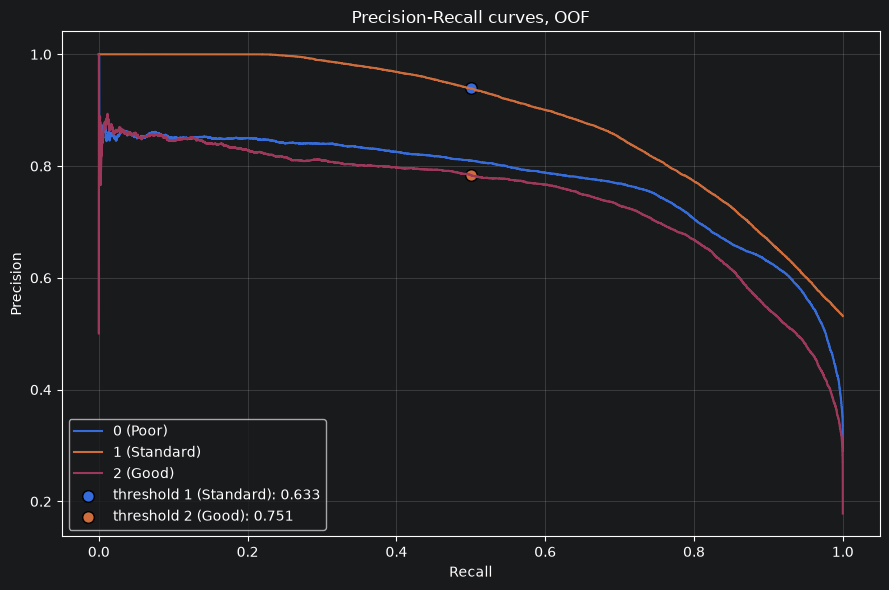

In [13]:
plt.figure(figsize=(9, 6))
for class_name, curve in pr_curves.items():
    plt.plot(curve["recall"], curve["precision"], label=class_name)

for _, row in threshold_selection_df.iterrows():
    plt.scatter(
        row["recall_at_threshold"],
        row["precision_at_threshold"],
        s=70,
        marker="o",
        edgecolor="black",
        label=f"threshold {row['class']}: {row['threshold']:.3f}",
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curves, OOF")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [14]:
pr_curve_points = pd.Series(
    {class_name: len(curve) for class_name, curve in pr_curves.items()},
    name="points",
)
display(pr_curve_points.to_frame())


,points
0 (Poor),79996
1 (Standard),79996
2 (Good),79996
